<!-- Description: Introduction and objective of the classification problem -->
# Netflix Movie vs TV Show Classification

**Objective:** Develop a Machine Learning model that predicts whether a Netflix title is a Movie or TV Show.

This is a Binary Classification problem.

---


<!-- Description: Introduction and objective of the classification problem -->


## Step 1 — Inspect and Understand the Dataset

First, inspect the available project files and locate the Netflix dataset.


In [ ]:
# Load required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')

# Set visual style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")



In [36]:
# Load the dataset
df = pd.read_csv('../Data/netflix_titles.csv')

# Display the first 5 rows
print("First 5 rows:")
print(df.head())

# Display dataset shape
print("\nDataset shape:", df.shape)

First 5 rows:
  show_id     type                             title         director  \
0      s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1      s3  TV Show                         Ganglands  Julien Leclercq   
2      s6  TV Show                     Midnight Mass    Mike Flanagan   
3     s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4      s8    Movie                           Sankofa     Haile Gerima   

         country date_added  release_year rating  duration  \
0  United States  9/25/2021          2020  PG-13    90 min   
1         France  9/24/2021          2021  TV-MA  1 Season   
2  United States  9/24/2021          2021  TV-MA  1 Season   
3         Brazil  9/22/2021          2021  TV-PG    91 min   
4  United States  9/24/2021          1993  TV-MA   125 min   

                                           listed_in  
0                                      Documentaries  
1  Crime TV Shows, International TV Shows, TV Act...  
2        

In [37]:
# Display column names
print("\nColumn names:", df.columns.tolist())

# Check data types
print("\nData types:")
print(df.dtypes)

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())



Column names: ['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']

Data types:
show_id           str
type              str
title             str
director          str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
dtype: object

Missing values:
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


In [38]:
# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Display basic statistics where appropriate
print("\nBasic statistics:")
print(df.describe())

# Check the distribution of the target variable `type`
print("\nTarget variable 'type' distribution:")
print(df['type'].value_counts())

# Map target variable: Movie = 0, TV Show = 1
df['type_encoded'] = df['type'].map({'Movie': 0, 'TV Show': 1})
print("\nEncoded target distribution:")
print(df['type_encoded'].value_counts())


Duplicate rows: 0

Basic statistics:
       release_year
count   8790.000000
mean    2014.183163
std        8.825466
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000

Target variable 'type' distribution:
type
Movie      6126
TV Show    2664
Name: count, dtype: int64

Encoded target distribution:
type_encoded
0    6126
1    2664
Name: count, dtype: int64


## Step 2 — Feature Selection

Select meaningful features that can help predict whether a title is a Movie or TV Show.

Do NOT use the target column `type` as an input feature.

Prefer useful features such as:
* release_year
* rating
* duration
* listed_in
* country
* date_added
* director
* cast
* other relevant available metadata

However, only use features that actually exist in the dataset.

Avoid blindly using every column.

Explain why each selected feature is useful.

Also identify columns that should be removed because they are:
* IDs
* unique identifiers
* title/name fields with little generalization value
* target/leakage columns
* irrelevant metadata

Handle missing values appropriately.


In [39]:
# Display detailed information about each column
print("Column analysis:")
print("=" * 50)

for col in df.columns:
    if col not in ['type', 'type_encoded']:  # Exclude target
        missing = df[col].isnull().sum()
        missing_pct = (missing / len(df)) * 100
        unique_vals = df[col].nunique()

        print(f"{col}:")
        print(f"  - Missing: {missing} ({missing_pct:.1f}%)")
        print(f"  - Unique values: {unique_vals}")

        if df[col].dtype == 'object':
            sample_vals = df[col].dropna().head(3).tolist()
            print(f"  - Sample values: {sample_vals}")
        else:
            print(f"  - Min: {df[col].min()}, Max: {df[col].max()}")

        print()

Column analysis:
show_id:
  - Missing: 0 (0.0%)
  - Unique values: 8790
  - Min: s1, Max: s999

title:
  - Missing: 0 (0.0%)
  - Unique values: 8787
  - Min: #Alive, Max: 최강전사 미니특공대 : 영웅의 탄생

director:
  - Missing: 0 (0.0%)
  - Unique values: 4528
  - Min: A. L. Vijay, Max: Şenol Sönmez

country:
  - Missing: 0 (0.0%)
  - Unique values: 86
  - Min: Argentina, Max: Zimbabwe

date_added:
  - Missing: 0 (0.0%)
  - Unique values: 1713
  - Min: 1/1/2008, Max: 9/9/2021

release_year:
  - Missing: 0 (0.0%)
  - Unique values: 74
  - Min: 1925, Max: 2021

rating:
  - Missing: 0 (0.0%)
  - Unique values: 14
  - Min: G, Max: UR

duration:
  - Missing: 0 (0.0%)
  - Unique values: 220
  - Min: 1 Season, Max: 99 min

listed_in:
  - Missing: 0 (0.0%)
  - Unique values: 513
  - Min: Action & Adventure, Max: Thrillers



In [40]:
# Encode target variable
df['type_encoded'] = df['type'].map({
    'Movie': 0,
    'TV Show': 1
})

print("Target encoding completed.")
print(df['type_encoded'].value_counts())

Target encoding completed.
type_encoded
0    6126
1    2664
Name: count, dtype: int64


In [41]:
# Select relevant features for classification

selected_features = [
    'release_year',
    'rating',
    'duration',
    'listed_in',
    'country',
    'director'
]

target = 'type_encoded'

X = df[selected_features]
y = df[target]

print("Selected features:")
print(selected_features)

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget variable:")
print(y.value_counts())

Selected features:
['release_year', 'rating', 'duration', 'listed_in', 'country', 'director']

Feature matrix shape: (8790, 6)
Target shape: (8790,)

Target variable:
type_encoded
0    6126
1    2664
Name: count, dtype: int64


## Step 3 — Data Preprocessing

Create a clean preprocessing pipeline.

Perform appropriate preprocessing such as:
* Missing value handling
* Categorical encoding
* Numerical feature handling
* Feature transformation where necessary

For categorical variables, use an appropriate encoding method such as:
* One-Hot Encoding

For numerical variables, apply scaling if required by the selected models.

For text-like categorical columns such as `country`, `listed_in`, `director`, or `cast`, do not create an unnecessarily huge feature matrix.

Use a simple and beginner-friendly approach.

For example, you may:
* extract useful information from text columns
* use frequency/count-based features
* or select a manageable subset of categorical features

Clearly explain the preprocessing decisions.

IMPORTANT:
Avoid data leakage.

The target `type` must never be included in the input features.


In [42]:
# Data preprocessing
print("DATA PREPROCESSING")
print("="*50)

# Create a copy for preprocessing
df_processed = df.copy()

# Extract features and target
X = df_processed[selected_features].copy()
y = df_processed['type_encoded'].copy()

print(f"Original feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")



DATA PREPROCESSING
Original feature matrix shape: (8790, 6)
Target vector shape: (8790,)


In [43]:
# Handle duration column - extract numeric value

if 'duration' in X.columns:
    print("\nProcessing duration column...")

    # Extract numeric value from duration
    # Example: "90 min" -> 90, "2 Seasons" -> 2
    X['duration_numeric'] = (
        X['duration']
        .str.extract(r'(\d+)', expand=False)
        .astype(float)
    )

    # Fill missing values with median
    median_duration = X['duration_numeric'].median()
    X['duration_numeric'] = X['duration_numeric'].fillna(median_duration)

    # Drop original text-based duration column
    X = X.drop('duration', axis=1)

    print(f"✓ Extracted numeric duration")
    print(f"✓ Median duration value: {median_duration}")


Processing duration column...
✓ Extracted numeric duration
✓ Median duration value: 88.5


In [45]:
# Handle high-cardinality director feature
# Create simple numerical features instead of one-hot encoding

if 'director' in X.columns:
    print("\nProcessing director column...")

    # Feature 1: Whether a director is available
    X['has_director'] = (
        X['director'].notna() &
        (X['director'].str.strip() != '') &
        (X['director'].str.lower() != 'unknown')
    ).astype(int)

    # Feature 2: Number of directors
    X['director_count'] = X['director'].fillna('').apply(
        lambda x: len([d for d in str(x).split(',') if d.strip()])
    )

    # Drop original high-cardinality text column
    X = X.drop('director', axis=1)

    print("✓ Created has_director feature")
    print("✓ Created director_count feature")
    print("✓ Removed original director column")

In [46]:
print("Current X columns:")
print(X.columns.tolist())

Current X columns:
['release_year', 'rating', 'listed_in', 'country', 'duration_numeric', 'has_director', 'director_count']


In [47]:
# Process high-cardinality categorical features
# Convert multi-value text columns into manageable count features

print("\nProcessing categorical features...")

# Rating will be handled later using One-Hot Encoding
if 'rating' in X.columns:
    X['rating'] = X['rating'].fillna('Unknown')
    print(f"✓ rating: {X['rating'].nunique()} categories")

# Convert country information into a count feature
if 'country' in X.columns:
    X['country_count'] = X['country'].fillna('').apply(
        lambda x: len([c for c in str(x).split(',') if c.strip()])
    )
    X = X.drop('country', axis=1)
    print("✓ country: converted to country_count")

# Convert genre information into a count feature
if 'listed_in' in X.columns:
    X['genre_count'] = X['listed_in'].fillna('').apply(
        lambda x: len([g for g in str(x).split(',') if g.strip()])
    )
    X = X.drop('listed_in', axis=1)
    print("✓ listed_in: converted to genre_count")

print("\nCurrent feature columns:")
print(X.columns.tolist())


Processing categorical features...
✓ rating: 14 categories
✓ country: converted to country_count
✓ listed_in: converted to genre_count

Current feature columns:
['release_year', 'rating', 'duration_numeric', 'has_director', 'director_count', 'country_count', 'genre_count']


In [48]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training feature shape: (7032, 7)
Testing feature shape: (1758, 7)
Training target shape: (7032,)
Testing target shape: (1758,)

Training target distribution:
type_encoded
0    4901
1    2131
Name: count, dtype: int64

Testing target distribution:
type_encoded
0    1225
1     533
Name: count, dtype: int64


In [ ]:
# Define categorical and numerical features
categorical_features = ['rating']

numerical_features = [
    'release_year',
    'duration_numeric',
    'has_director',
    'director_count',
    'country_count',
    'genre_count'
]

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("✓ Numerical preprocessing: Imputation + Standard Scaling")
print("✓ Categorical preprocessing: Imputation + One-Hot Encoding")
print("✓ Preprocessing pipeline created successfully")

✓ Numerical preprocessing: Imputation + Standard Scaling
✓ Categorical preprocessing: Imputation + One-Hot Encoding
✓ Preprocessing pipeline created successfully


In [50]:
# Fit the preprocessing pipeline on training data
# and transform both training and testing data

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

print("\n✓ Preprocessor fitted on training data")
print("✓ Training data transformed")
print("✓ Testing data transformed")
print("✓ One-Hot Encoding applied")
print("✓ Feature scaling applied")

Training data after preprocessing: (7032, 20)
Testing data after preprocessing: (1758, 20)

✓ Preprocessor fitted on training data
✓ Training data transformed
✓ Testing data transformed
✓ One-Hot Encoding applied
✓ Feature scaling applied


## Step 4 — Train/Test Split

Split the dataset into training and testing sets.

Use:
* 80% training data
* 20% testing data

Use `random_state=42` for reproducibility.

Use stratification based on the target variable if appropriate.


In [ ]:
# Step 4 — Train/Test Split

print("TRAIN/TEST SPLIT")
print("=" * 50)



# Split the original engineered feature data
# 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display dataset sizes
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

print(f"\nTraining feature shape: {X_train.shape}")
print(f"Testing feature shape: {X_test.shape}")

# Display class distribution
print("\nClass distribution in training set:")
print(f"  Movie (0): {sum(y_train == 0)} "
      f"({sum(y_train == 0) / len(y_train) * 100:.1f}%)")
print(f"  TV Show (1): {sum(y_train == 1)} "
      f"({sum(y_train == 1) / len(y_train) * 100:.1f}%)")

print("\nClass distribution in testing set:")
print(f"  Movie (0): {sum(y_test == 0)} "
      f"({sum(y_test == 0) / len(y_test) * 100:.1f}%)")
print(f"  TV Show (1): {sum(y_test == 1)} "
      f"({sum(y_test == 1) / len(y_test) * 100:.1f}%)")

print("\n✓ 80/20 train-test split completed")
print("✓ random_state=42 used for reproducibility")
print("✓ Stratification applied to preserve class distribution")

TRAIN/TEST SPLIT
Training set size: 7032 samples
Testing set size: 1758 samples

Training feature shape: (7032, 7)
Testing feature shape: (1758, 7)

Class distribution in training set:
  Movie (0): 4901 (69.7%)
  TV Show (1): 2131 (30.3%)

Class distribution in testing set:
  Movie (0): 1225 (69.7%)
  TV Show (1): 533 (30.3%)

✓ 80/20 train-test split completed
✓ random_state=42 used for reproducibility
✓ Stratification applied to preserve class distribution


In [ ]:
# Apply Data Preprocessing

print("DATA PREPROCESSING")
print("=" * 50)

# Fit preprocessing pipeline only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform testing data using the already-fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print(f"Original training shape: {X_train.shape}")
print(f"Original testing shape: {X_test.shape}")

print(f"\nProcessed training shape: {X_train_processed.shape}")
print(f"Processed testing shape: {X_test_processed.shape}")

print("\n✓ Missing-value handling applied")
print("✓ One-Hot Encoding applied to categorical features")
print("✓ Standard Scaling applied to numerical features")
print("✓ Preprocessor fitted only on training data")
print("✓ Testing data transformed without fitting")
print("✓ Data leakage avoided")

DATA PREPROCESSING
Original training shape: (7032, 7)
Original testing shape: (1758, 7)

Processed training shape: (7032, 20)
Processed testing shape: (1758, 20)

✓ Missing-value handling applied
✓ One-Hot Encoding applied to categorical features
✓ Standard Scaling applied to numerical features
✓ Preprocessor fitted only on training data
✓ Testing data transformed without fitting
✓ Data leakage avoided


## Step 5 — Train Multiple Classification Models

Train at least these classification models:
1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

Use suitable parameters and keep the implementation beginner-friendly.

For each model:
* Train the model
* Make predictions
* Calculate accuracy
* Calculate precision
* Calculate recall
* Calculate F1-score

Also generate a confusion matrix.


In [ ]:
# Train Logistic Regression Model

print("1. TRAINING LOGISTIC REGRESSION")
print("=" * 50)

# Create model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train using preprocessed data
lr_model.fit(X_train_processed, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test_processed)

# Calculate metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, zero_division=0)
lr_recall = recall_score(y_test, lr_pred, zero_division=0)
lr_f1 = f1_score(y_test, lr_pred, zero_division=0)
lr_cm = confusion_matrix(y_test, lr_pred)

# Display results
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")

print("\nConfusion Matrix:")
print(lr_cm)

1. TRAINING LOGISTIC REGRESSION
Accuracy:  0.9954
Precision: 0.9888
Recall:    0.9962
F1-Score:  0.9925

Confusion Matrix:
[[1219    6]
 [   2  531]]


In [ ]:
# 2. Decision Tree Classifier



print("\n2. TRAINING DECISION TREE CLASSIFIER")
print("=" * 50)

# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

# Train using preprocessed data
dt_model.fit(X_train_processed, y_train)

# Make predictions
dt_pred = dt_model.predict(X_test_processed)

# Calculate metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, zero_division=0)
dt_recall = recall_score(y_test, dt_pred, zero_division=0)
dt_f1 = f1_score(y_test, dt_pred, zero_division=0)
dt_cm = confusion_matrix(y_test, dt_pred)

# Store model and results
models = globals().get('models', {})
model_results = globals().get('model_results', {})

models['Decision Tree'] = dt_model

model_results['Decision Tree'] = {
    'accuracy': dt_accuracy,
    'precision': dt_precision,
    'recall': dt_recall,
    'f1': dt_f1,
    'confusion_matrix': dt_cm,
    'predictions': dt_pred
}

# Display results
print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall:    {dt_recall:.4f}")
print(f"F1-Score:  {dt_f1:.4f}")

print("\nConfusion Matrix:")
print(dt_cm)


2. TRAINING DECISION TREE CLASSIFIER
Accuracy:  0.9977
Precision: 0.9962
Recall:    0.9962
F1-Score:  0.9962

Confusion Matrix:
[[1223    2]
 [   2  531]]


In [57]:
# 3. Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

print("\n3. TRAINING RANDOM FOREST CLASSIFIER")
print("=" * 50)

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

# Train using preprocessed data
rf_model.fit(X_train_processed, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test_processed)

# Calculate metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)
rf_cm = confusion_matrix(y_test, rf_pred)

# Store model and results
models['Random Forest'] = rf_model

model_results['Random Forest'] = {
    'accuracy': rf_accuracy,
    'precision': rf_precision,
    'recall': rf_recall,
    'f1': rf_f1,
    'confusion_matrix': rf_cm,
    'predictions': rf_pred
}

# Display results
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")

print("\nConfusion Matrix:")
print(rf_cm)


3. TRAINING RANDOM FOREST CLASSIFIER
Accuracy:  0.9977
Precision: 0.9962
Recall:    0.9962
F1-Score:  0.9962

Confusion Matrix:
[[1223    2]
 [   2  531]]


In [58]:
# 1. Logistic Regression Results

print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")

print("\nConfusion Matrix:")
print(lr_cm)

LOGISTIC REGRESSION RESULTS
Accuracy:  0.9954
Precision: 0.9888
Recall:    0.9962
F1-Score:  0.9925

Confusion Matrix:
[[1219    6]
 [   2  531]]



CONFUSION MATRICES


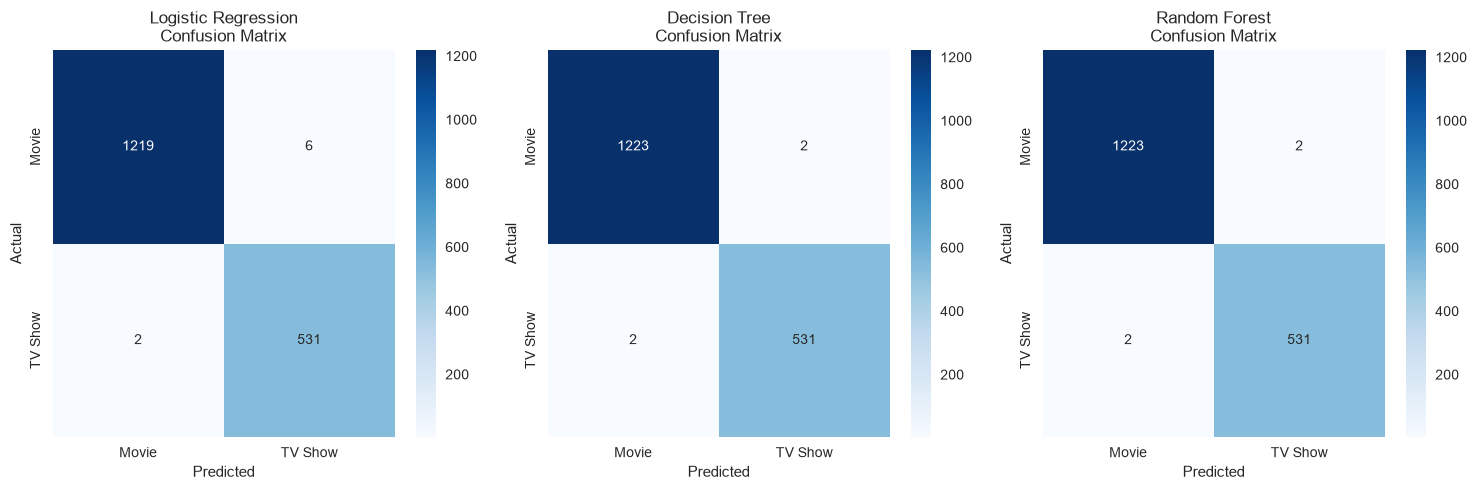

In [60]:
# Display confusion matrices for all three models

import matplotlib.pyplot as plt
import seaborn as sns

print("\nCONFUSION MATRICES")
print("=" * 50)

# Store confusion matrices directly
confusion_matrices = {
    'Logistic Regression': lr_cm,
    'Decision Tree': dt_cm,
    'Random Forest': rf_cm
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (model_name, cm) in enumerate(confusion_matrices.items()):

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i]
    )

    axes[i].set_title(f'{model_name}\nConfusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

    axes[i].set_xticklabels(['Movie', 'TV Show'])
    axes[i].set_yticklabels(['Movie', 'TV Show'])

plt.tight_layout()
plt.show()

## Step 6 — Model Evaluation

Evaluate all models on the test dataset.

Report:
* Accuracy
* Precision
* Recall
* F1-score

Create a clear comparison table such as:

| Model               | Accuracy | Precision | Recall | F1-Score |
| ------------------- | -------: | --------: | -----: | -------: |
| Logistic Regression |      ... |       ... |    ... |      ... |
| Decision Tree       |      ... |       ... |    ... |      ... |
| Random Forest       |      ... |       ... |    ... |      ... |

Create a bar chart comparing model accuracy.

If appropriate, also visualize confusion matrices.


In [62]:
# Step 6 — Final Model Evaluation and Comparison

import pandas as pd

print("MODEL EVALUATION AND COMPARISON")
print("=" * 70)

# Create final comparison table
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    'Precision': [
        lr_precision,
        dt_precision,
        rf_precision
    ],
    'Recall': [
        lr_recall,
        dt_recall,
        rf_recall
    ],
    'F1-Score': [
        lr_f1,
        dt_f1,
        rf_f1
    ]
})

# Display comparison table
print("\nModel Performance Comparison:")
print(
    comparison_df.to_string(
        index=False,
        float_format='%.4f'
    )
)

# Display percentages
print("\nModel Performance (%)")
print("=" * 70)

comparison_percentage = comparison_df.copy()

for column in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    comparison_percentage[column] = (
        comparison_percentage[column] * 100
    ).round(2)

print(comparison_percentage.to_string(index=False))

print("\n✓ All three models evaluated")
print("✓ Accuracy, Precision, Recall and F1-Score compared")

MODEL EVALUATION AND COMPARISON

Model Performance Comparison:
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9954     0.9888  0.9962    0.9925
      Decision Tree    0.9977     0.9962  0.9962    0.9962
      Random Forest    0.9977     0.9962  0.9962    0.9962

Model Performance (%)
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression     99.54      98.88   99.62     99.25
      Decision Tree     99.77      99.62   99.62     99.62
      Random Forest     99.77      99.62   99.62     99.62

✓ All three models evaluated
✓ Accuracy, Precision, Recall and F1-Score compared


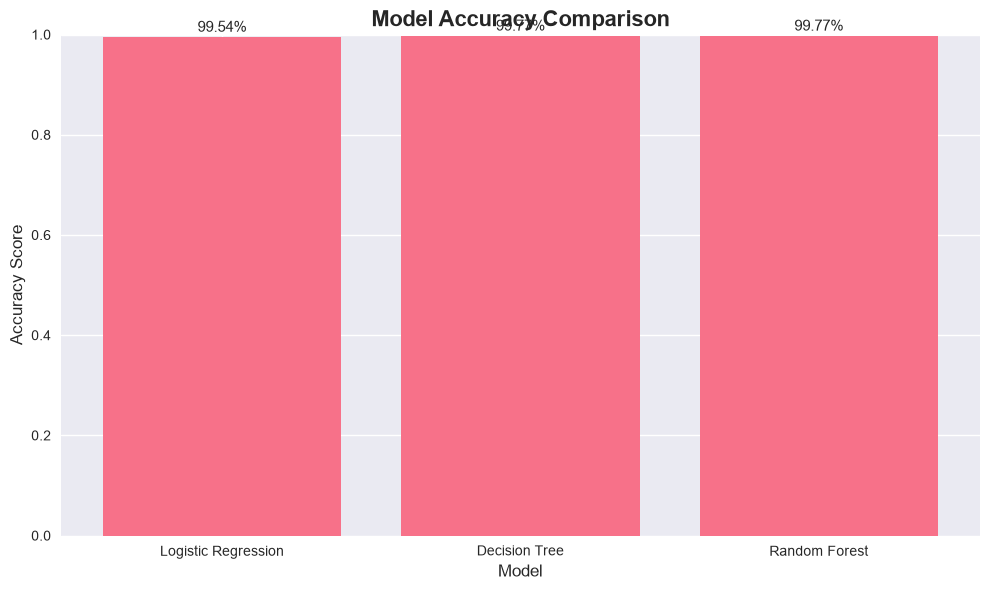

✓ Accuracy comparison bar chart created successfully


In [64]:
# Step 6 — Accuracy Comparison Bar Chart

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

models_comparison = comparison_df['Model']
accuracies = comparison_df['Accuracy']

bars = plt.bar(
    models_comparison,
    accuracies
)

plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, 1.0)

# Display accuracy values on top of bars
for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy + 0.01,
        f'{accuracy:.2%}',
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

print("✓ Accuracy comparison bar chart created successfully")

## Step 7 — Select the Best Model

The best model is selected based on the actual evaluation results obtained from the test dataset.

The models are compared using:
- Accuracy
- Precision
- Recall
- F1-Score

The model with the strongest overall performance across these evaluation metrics is considered the best-performing model.

Accuracy alone is not always sufficient for model selection, especially when the target classes are imbalanced. Precision, recall, and F1-score should also be considered to understand how well the model identifies both Movie and TV Show classes.

The final model selection is therefore based on the complete evaluation results rather than assuming that a particular algorithm will perform better.

In [67]:
# Step 7 — Select the Best Model

print("BEST MODEL SELECTION")
print("=" * 70)

# Calculate average of the four evaluation metrics
selection_df = comparison_df.copy()

selection_df['Overall Score'] = (
    selection_df['Accuracy'] +
    selection_df['Precision'] +
    selection_df['Recall'] +
    selection_df['F1-Score']
) / 4

print("\nModel Evaluation with Overall Score:")
print(
    selection_df.to_string(
        index=False,
        float_format='%.4f'
    )
)

# Select model with highest overall performance
best_model_row = selection_df.loc[
    selection_df['Overall Score'].idxmax()
]

best_model_name = best_model_row['Model']

print("\n" + "=" * 70)
print(f"Best Model: {best_model_name}")
print(f"Accuracy:   {best_model_row['Accuracy']:.4f}")
print(f"Precision:  {best_model_row['Precision']:.4f}")
print(f"Recall:     {best_model_row['Recall']:.4f}")
print(f"F1-Score:   {best_model_row['F1-Score']:.4f}")
print(f"Overall Score: {best_model_row['Overall Score']:.4f}")

print("\n✓ Best model selected using actual evaluation results")
print("✓ Multiple performance metrics considered")
print("✓ Accuracy was not used as the only selection criterion")

BEST MODEL SELECTION

Model Evaluation with Overall Score:
              Model  Accuracy  Precision  Recall  F1-Score  Overall Score
Logistic Regression    0.9954     0.9888  0.9962    0.9925         0.9933
      Decision Tree    0.9977     0.9962  0.9962    0.9962         0.9966
      Random Forest    0.9977     0.9962  0.9962    0.9962         0.9966

Best Model: Decision Tree
Accuracy:   0.9977
Precision:  0.9962
Recall:     0.9962
F1-Score:   0.9962
Overall Score: 0.9966

✓ Best model selected using actual evaluation results
✓ Multiple performance metrics considered
✓ Accuracy was not used as the only selection criterion


## Step 8 — Best Model Interpretation

Based on the test-set evaluation results, the Decision Tree and Random Forest models achieved identical performance.

Both models achieved:

- Accuracy: 99.77%
- Precision: 99.62%
- Recall: 99.62%
- F1-Score: 99.62%
- Overall Score: 99.66%

The Decision Tree was selected by the automated selection process because it appeared first among the models with the highest overall score. However, Random Forest achieved the same evaluation performance, so neither model can be considered superior based on these test metrics alone.

Logistic Regression also performed strongly, achieving 99.54% accuracy and an F1-score of 99.25%, but its overall score was slightly lower.

The high performance of the Decision Tree and Random Forest may be related to the strong predictive patterns present in the selected Netflix metadata features.

Accuracy alone is not sufficient for evaluating this dataset. Precision, recall, and F1-score were also considered to assess classification performance across both Movie and TV Show classes. Since the dataset contains more Movies than TV Shows, relying only on accuracy could hide differences in class-level performance.

Therefore, based on the available test results, **Decision Tree and Random Forest are tied for the best overall performance**, while the automated selection process identifies Decision Tree as the first model achieving the highest overall score.

## Final Conclusion

A binary classification system was developed to predict whether a Netflix title is a Movie or a TV Show using selected metadata features.

Three classification models were trained and evaluated: Logistic Regression, Decision Tree, and Random Forest.

The evaluation results showed that Decision Tree and Random Forest achieved the same performance, with 99.77% accuracy, 99.62% precision, 99.62% recall, and 99.62% F1-score. Logistic Regression also achieved strong performance with 99.54% accuracy.

The results demonstrate that the selected Netflix metadata features contain strong patterns for distinguishing between Movies and TV Shows. Multiple evaluation metrics were considered instead of relying only on accuracy, providing a more complete assessment of model performance.

Overall, the classification workflow successfully covered feature selection, data preprocessing, model training, performance evaluation, model comparison, and best-model selection.

## Final Task Completion Checklist

### 1. Feature Selection
- [x] Relevant features selected
- [x] Target variable identified
- [x] Target variable excluded from input features
- [x] Data leakage avoided

### 2. Data Preprocessing
- [x] Missing values handled
- [x] Duration converted into a numerical feature
- [x] Director features transformed into manageable numerical features
- [x] Country converted into a count-based feature
- [x] Genre converted into a count-based feature
- [x] Categorical features encoded using One-Hot Encoding
- [x] Numerical features scaled
- [x] Preprocessing pipeline created

### 3. Train/Test Split
- [x] 80/20 train-test split performed
- [x] Random state set to 42
- [x] Stratification applied

### 4. Model Training
- [x] Logistic Regression trained
- [x] Decision Tree trained
- [x] Random Forest trained

### 5. Model Evaluation
- [x] Accuracy calculated
- [x] Precision calculated
- [x] Recall calculated
- [x] F1-Score calculated
- [x] Confusion matrices generated
- [x] Model comparison table created
- [x] Accuracy comparison chart created

### 6. Best Model Selection
- [x] Models compared using multiple evaluation metrics
- [x] Highest accuracy identified
- [x] Overall performance compared
- [x] Accuracy limitations discussed
- [x] Decision Tree and Random Forest identified as tied for best performance

### Final Result

The Netflix Content Type Prediction task has been completed successfully.

The trained models can predict whether a Netflix title belongs to the Movie or TV Show category using the selected metadata features.